In [118]:
import numpy as np 
import matplotlib.pyplot as plt

In [ ]:
rosenbrock = lambda v: 100*(v[1] - v[0]**2)**2 + (1 - v[0])**2
f = lambda v: v[0]**4 + 2*v[0]**2



x = np.linspace(-4, 4, 200)
y = np.linspace(-4, 4, 200)

In [120]:
def numerical_gradient(f, x, h=1e-5):
    x = np.asarray(x, dtype=float)
    grad = np.zeros_like(x)
    for i in range(len(x)):
        x_fwd, x_bwd = x.copy(), x.copy()
        x_fwd[i] += h
        x_bwd[i] -= h
        grad[i] = (f(x_fwd) - f(x_bwd)) / (2*h)
    return grad


def numerical_hessian(f, x, h=1e-4):
    x = np.asarray(x, dtype=float)
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            xpp, xpm, xmp, xmm = x.copy(), x.copy(), x.copy(), x.copy()
            xpp[i] += h; xpp[j] += h
            xpm[i] += h; xpm[j] -= h
            xmp[i] -= h; xmp[j] += h
            xmm[i] -= h; xmm[j] -= h
            H[i, j] = (f(xpp) - f(xpm) - f(xmp) + f(xmm)) / (4*h*h)
    return H

def taylor_series_approx(f, x0, x):
    """2nd-order Taylor approx of f around x0, evaluated at x.

    f(x) ~= f(x0) + g.d + 0.5 * d^T H d,   d = x - x0
    """
    x0 = np.asarray(x0, dtype=float)
    x = np.asarray(x, dtype=float)
    d = x - x0
    g = numerical_gradient(f, x0)
    H = numerical_hessian(f, x0)
    return f(x0) + g @ d + 0.5 * d @ H @ d

In [ ]:
def plot_contour_with_path(path, func, x=x, y=y):
    X, Y = np.meshgrid(x, y)
    Z = func([X, Y])

    plt.contourf(X, Y, np.log1p(Z), levels=30, cmap='viridis')
    plt.colorbar(label='log(1 + f(x,y))')
    plt.plot(path[:, 0], path[:, 1], 'w.-', label='path')
    plt.plot(path[0, 0], path[0, 1], 'go', markersize=10, label='start')
    plt.plot(path[-1, 0], path[-1, 1], 'r*', markersize=15, label='end')
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_1v_path(path, f, xs=x):
    plt.plot(xs, f([xs]), label='f(x)')          # 1D: uses v[0]
    plt.plot(path, f([path]), 'r.-', label='path')
    plt.plot(path[0],  f([path[0]]),  'go', markersize=10, label='start')
    plt.plot(path[-1], f([path[-1]]), 'r*', markersize=15, label='end')
    plt.legend(); plt.xlabel('x'); plt.ylabel('f(x)')
    plt.show()

In [122]:
def newton_method_id(x0, i, grad1, grad2):
    p = np.asarray(x0, dtype=float)
    path = [p.copy()]
    for _ in range(i-1):
        p = p - (grad1(p) / grad2(p))
        path.append(p.copy())
    return path

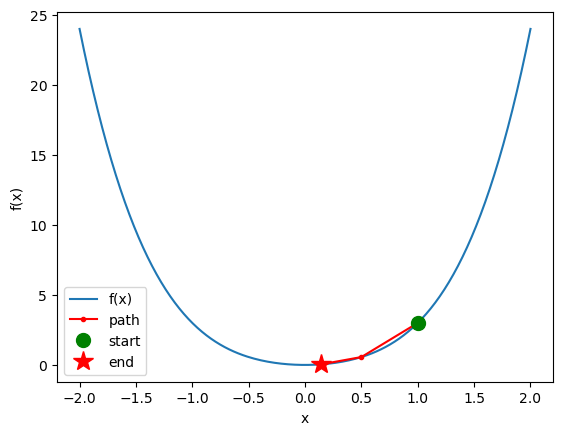

path: [1.         0.5        0.14285714]


In [ ]:
grad1 = lambda x: 4*x**3 + 4*x
grad2 = lambda x: 12*x**2 + 4
path = newton_method_id(np.array(1.0), 3, grad1, grad2)
path = np.array(path)


print("path:", path)

In [124]:
def newton_method_bid(x0, i, gradf, H):
    Hinv  = np.linalg.inv(H)
    p = np.asarray(x0, dtype=float)
    path = [p.copy()]
    for _ in range(i-1):
        g = gradf(p[0], p[1])
        p = p - Hinv @ g
        path.append(p.copy())
    return np.array(path)

In [125]:
gradf = lambda x, y: np.array([2*x, 8*y])
H = np.array([[2, 0],[0, 8]])
x0 = np.array([3.0, 2.0])

path = newton_method_bid(x0, 3, gradf, H)
print("final:", path[-1]) 
print(path)

final: [0. 0.]
[[3. 2.]
 [0. 0.]
 [0. 0.]]


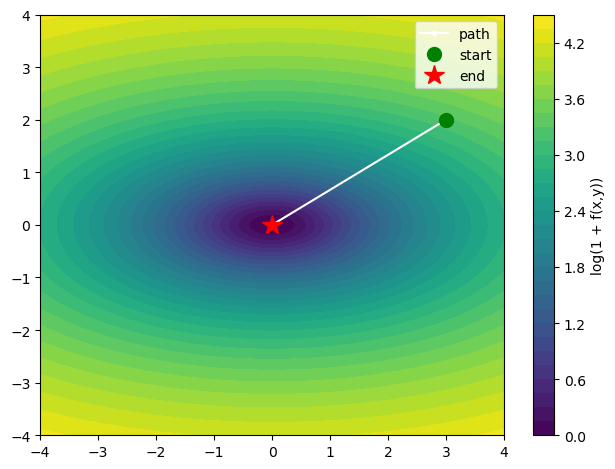

In [ ]:
f = lambda v: v[0]**2 + 4*v[1]**2     # matches gradf/H above
plot_contour_with_path(path, f)